# Reviewer walkthrough — Market Experiments with LLM Agents (Multi-Agent Systems, Experimental Economics)

**Purpose:** verify every number behind the resume points in ~3 minutes. This notebook only
*loads committed result files* — no training, no downloads, **no API key**. Full provenance: `CLAIMS.md`;
full verification: `REPRODUCING.md` (key-less fresh-machine log: `results/fresh_machine_run.log`).


## Point 1 — *Three canonical experiments on a bit-exact-replayable engine*
Calibration certificate first: budget-constrained zero-intelligence traders (ZI-C) must reproduce the
Gode–Sunder result before any LLM claim is believed. Every statistic below recomputes from committed
session logs; the engine replays any session bit-exactly (property-tested).

In [1]:
import json, pandas as pd
def cells(exp):
    s = json.load(open(f"../results/{exp}/summary.json"))["cells"]
    return pd.DataFrame({c: {k: v for k, v in d.items() if isinstance(v, (int, float))} for c, d in s.items()}).T
zi = cells("zi_baseline"); display(zi)
zic = [c for c in zi.index if "zi_c" in c or c.endswith("_c")][0]
assert zi.loc[zic, "mean_efficiency"] > 0.9
print(f"ASSERT OK: ZI-C efficiency {zi.loc[zic,'mean_efficiency']:.3f} — Gode–Sunder replicates (the control the LLM must beat)")

,mean_efficiency,n_sessions
zi_c,0.927943,50.0
zi_u,-0.214093,50.0


ASSERT OK: ZI-C efficiency 0.928 — Gode–Sunder replicates (the control the LLM must beat)


## Point 2 — *The 8B LLM loses to zero-intelligence (H1 reversed)*
Seed-matched Smith double-auction markets, ≥30 sessions/cell, both instruction paraphrases (a/b).

In [2]:
sm = cells("smith_h1"); display(sm)
llm = min(v for c, v in sm["mean_efficiency"].items() if "llm" in c)
zic_eff = sm["mean_efficiency"][[c for c in sm.index if "zi" in c][0]]
print(f"LLM efficiency {llm:.2f} vs ZI-C {zic_eff:.2f}")
assert llm < 0.35 and zic_eff > 0.85
print("ASSERT OK: the LLM underperforms budget-constrained randomness in the same markets")

,mean_efficiency,n_sessions
llm_local_a,0.222686,30.0
llm_local_b,0.177406,30.0
zi_c,0.917713,30.0


LLM efficiency 0.18 vs ZI-C 0.92
ASSERT OK: the LLM underperforms budget-constrained randomness in the same markets


### The headline picture (visual anchor)
One chart for the whole project: mean allocative efficiency by trader type in identical, seed-matched
markets. Budget-constrained *randomness* (ZI-C) nearly saturates the market's possible gains; the LLM
does not come close — the institution, not the intelligence, does the work.

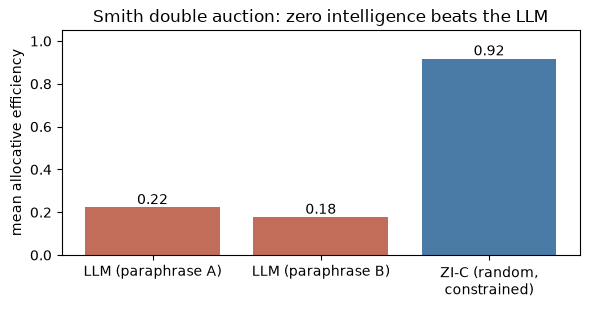

In [3]:
import matplotlib.pyplot as plt
sm = cells("smith_h1")["mean_efficiency"]
labels = {"zi_c": "ZI-C (random,\nconstrained)", "llm_local_a": "LLM (paraphrase A)", "llm_local_b": "LLM (paraphrase B)"}
names = [labels.get(i, i) for i in sm.index]
fig, ax = plt.subplots(figsize=(6, 3.2))
bars = ax.bar(names, sm.values, color=["#4a7ba6" if "ZI" in n else "#c26d5a" for n in names])
ax.bar_label(bars, fmt="%.2f"); ax.set_ylabel("mean allocative efficiency"); ax.set_ylim(0, 1.05)
ax.set_title("Smith double auction: zero intelligence beats the LLM")
plt.tight_layout()

## Point 3 — *No bubbles: markets price ~60% below fundamentals; experience halves mispricing*
Smith–Suchanek–Williams design. RD (relative deviation from fundamental value): humans in the
literature bubble (RD > 0); these markets *under*price. `_exp` = experienced cell (prior-session
summary in context).

In [4]:
ssw = cells("ssw_h2"); display(ssw)
rd_col = [c for c in ssw.columns if c in ("mean_rd", "rd_mean") or c.startswith("rd")][0]
inexp = [ssw.loc[c, rd_col] for c in ssw.index if "llm" in c and "exp" not in c]
exp = [ssw.loc[c, rd_col] for c in ssw.index if c.endswith("_exp")]
print(f"RD inexperienced: {[round(x,2) for x in inexp]} | experienced: {[round(x,2) for x in exp]}")
assert all(x < -0.4 for x in inexp) and all(abs(e) < abs(min(inexp)) for e in exp)
print("ASSERT OK: no bubbles (RD ~ -0.6), experience shrinks the mispricing")

,mean_rd,n_sessions
ssw_llm_a,-0.593862,30.0
ssw_llm_a_exp,-0.375227,30.0
ssw_llm_b,-0.594878,30.0
ssw_zi_c,0.824302,30.0


RD inexperienced: [np.float64(-0.59), np.float64(-0.59)] | experienced: [np.float64(-0.38)]
ASSERT OK: no bubbles (RD ~ -0.6), experience shrinks the mispricing


## Point 4 — *Dealers quoted 4.4× the competitive spread — passivity, not collusion*
Dealer duopoly vs a certified competitive (Nash) benchmark (myopic best-response agents converge to it
before any LLM runs). Deviation probes are the causal test: collusion punishes an undercutting rival;
*matching* (following the rival down) is the competition signature.

In [5]:
duo_raw = json.load(open("../results/duopoly_h3/summary.json"))["cells"]
rows = {}
for cell, d in duo_raw.items():
    sess = d["sessions"]
    nash = [2*x["mean_half_spread"] - x["markup"] for x in sess]
    obs = [2*x["mean_half_spread"] for x in sess]
    probe = [x["mean_probe_response"] for x in sess]
    rows[cell] = {"markup_francs": round(d["mean_markup"], 2),
                  "nash_spread": round(sum(nash)/len(nash), 3),
                  "observed_spread": round(sum(obs)/len(obs), 2),
                  "ratio_obs_over_nash": round(sum(obs)/len(obs) / (sum(nash)/len(nash)), 2),
                  "mean_probe_response": round(sum(probe)/len(probe), 2)}
display(pd.DataFrame(rows).T)
# CLAIMS H3-7: Nash spread is exactly 8 in every session (certified benchmark); ratios 4.43x / 3.17x
all_nash = [2*x["mean_half_spread"] - x["markup"] for d in duo_raw.values() for x in d["sessions"]]
assert all(abs(n - 8.0) < 1e-9 for n in all_nash), "Nash spread must be exactly 8 in every session"
ra = rows["duo_llm_a"]["ratio_obs_over_nash"]; rb = rows["duo_llm_b"]["ratio_obs_over_nash"]
assert abs(ra - 4.43) < 0.05 and abs(rb - 3.17) < 0.05, (ra, rb)
assert all(r["mean_probe_response"] < 0 for r in rows.values())
print(f"ASSERT OK: dealers quoted {ra}x / {rb}x the certified Nash spread (8.0 exact in all 60 sessions);")
print("negative probe responses = matching (competition signature), ruling out punishment-enforced collusion")

,markup_francs,nash_spread,observed_spread,ratio_obs_over_nash,mean_probe_response
duo_llm_a,27.42,8.0,35.42,4.43,-1.53
duo_llm_b,17.35,8.0,25.35,3.17,-1.99


ASSERT OK: dealers quoted 4.43x / 3.17x the certified Nash spread (8.0 exact in all 60 sessions);
negative probe responses = matching (competition signature), ruling out punishment-enforced collusion


---
**Resume-point → evidence:** P1 → `notebooks/01_exchange_and_zi.ipynb`, `02_llm_harness.ipynb`;
P2 → `03_smith_convergence.ipynb`; P3 → `04_ssw_bubbles.ipynb`; P4 → `05_duopoly_collusion.ipynb`.
Full check (no API key needed): `uv sync --frozen && uv run pytest -q` (194 gate tests).